# RCA Model Training & Evaluation (Full Results)

## 1. 전역 설정 및 라이브러리 로드

In [1]:
import os
import sys
import torch
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from pathlib import Path

def setup_scientific_path():
    candidate_roots = ['/home/user/t1-4', os.path.abspath('..'), os.getcwd()]
    for root in candidate_roots:
        if os.path.isdir(os.path.join(root, 'src')):
            if root not in sys.path: sys.path.insert(0, root)
            return root
    return None

ROOT_DIR = setup_scientific_path()
from src.hiertable_rag.core.rca_model import RCAModel
from scripts.universal_dataset import UniversalTableDataset
from src.evaluation.tsr_evaluator import TSREvaluator
from src.models.baselines.wrapper import RCAWrapper
from src.hiertable_rag.core.grid_restorer import IntersectionRestorer

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

/home/user/.pyenv/versions/3.11.6/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


In [2]:
def dice_loss(pred, target, smooth=1e-6):
    intersection = (pred * target).sum(dim=1)
    return 1 - ((2. * intersection + smooth) / (pred.sum(dim=1) + target.sum(dim=1) + smooth))

def rca_collate(batch):
    from torch.utils.data.dataloader import default_collate
    new_batch = []
    for sample in batch:
        new_sample = {k: v for k, v in sample.items() if k not in ["cells", "row_lines", "col_lines"]}
        new_batch.append(new_sample)
    return default_collate(new_batch)

In [3]:
BASE_DIR = "/home/user/t1-4/data/external"
dataset_type = "scitsr"
train_dataset = UniversalTableDataset(BASE_DIR, dataset_type, split="train")
val_dataset = UniversalTableDataset(BASE_DIR, dataset_type, split="val")
print(f"Loaded {len(train_dataset)} samples.")

Loaded 11998 samples.


In [4]:
model = RCAModel().to(device)
checkpoint_path = "/home/user/t1-4/outputs/rca_best.pth"
if os.path.exists(checkpoint_path):
    print(f"Loading existing model from {checkpoint_path}")
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
else:
    print("No checkpoint found.")

INFO:timm.models._builder:Loading pretrained weights from Hugging Face hub (timm/resnet18.a1_in1k)


INFO:timm.models._hub:[timm/resnet18.a1_in1k] Safe alternative available for 'pytorch_model.bin' (as 'model.safetensors'). Loading weights using safetensors.


INFO:timm.models._builder:Missing keys (fc.weight, fc.bias) discovered while loading pretrained weights. This is expected if model is being adapted.


Loading existing model from /home/user/t1-4/outputs/rca_best.pth


## 2. 정량적 평가 (TEDS)

In [5]:
restorer = IntersectionRestorer()
rca_wrapper = RCAWrapper(model, restorer)
evaluator = TSREvaluator(val_dataset, {"Trained_RCA": rca_wrapper})
evaluator.run_evaluation(num_samples=10)

if evaluator.results:
    df = pd.DataFrame(evaluator.results)
    print("\n--- Mean Metrics ---")
    print(df.mean())
else:
    print("Evaluation failed.")

Evaluating samples:   0%|                                                                            | 0/10 [00:00<?, ?it/s]

INFO:src.hiertable_rag.core.grid_restorer:[RCA] Restoring Cells from Global Intersections...


/home/user/.pyenv/versions/3.11.6/lib/python3.11/site-packages/apted/node_indexer.py:331: FutureWarning: Truth-testing of elements was a source of confusion and will always return True in future versions. Use specific 'len(elem)' or 'elem is not None' test instead.
  return bool(self.node)
Evaluating samples:  10%|██████▊                                                             | 1/10 [00:00<00:05,  1.58it/s]

INFO:src.hiertable_rag.core.grid_restorer:[RCA] Restoring Cells from Global Intersections...


INFO:src.hiertable_rag.core.grid_restorer:[RCA] Restoring Cells from Global Intersections...


...

INFO:src.hiertable_rag.core.grid_restorer:[RCA] Restoring Cells from Global Intersections...


Evaluating samples:  90%|█████████████████████████████████████████████████████████████▏      | 9/10 [00:00<00:00, 12.86it/s]

INFO:src.hiertable_rag.core.grid_restorer:[RCA] Restoring Cells from Global Intersections...


Evaluating samples: 100%|███████████████████████████████████████████████████████████████████| 10/10 [00:01<00:00,  9.65it/s]


--- Mean Metrics ---
index               1121.800000
Trained_RCA_TEDS       0.319798
dtype: float64


## 3. 시각화

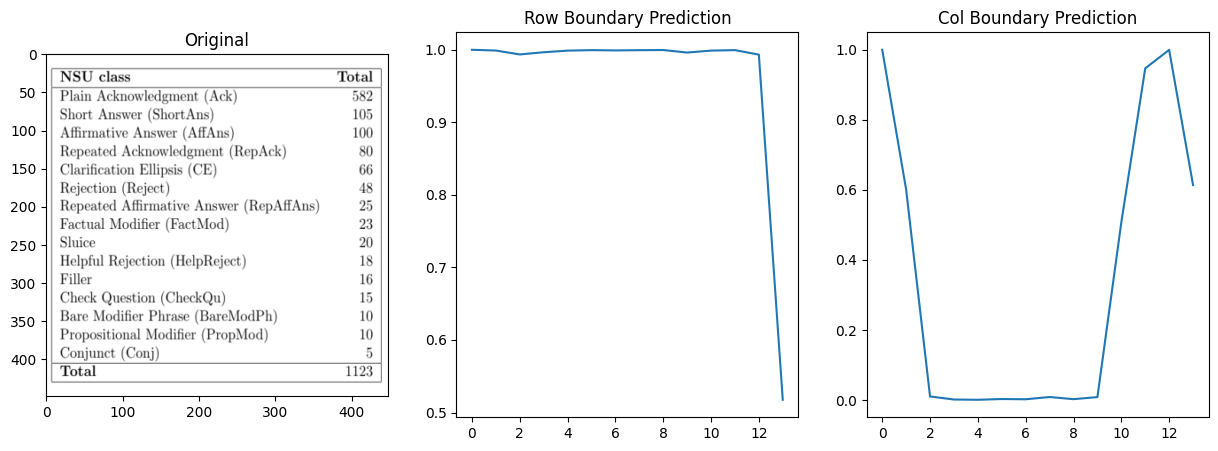

In [6]:
model.eval()
sample = val_dataset[0]
with torch.no_grad():
    out = model(sample["image"].unsqueeze(0).to(device))

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1); plt.imshow(sample["image"].permute(1,2,0)); plt.title("Original")
plt.subplot(1, 3, 2); plt.plot(out["row_probs"][0].cpu()); plt.title("Row Boundary Prediction")
plt.subplot(1, 3, 3); plt.plot(out["col_probs"][0].cpu()); plt.title("Col Boundary Prediction")
plt.show()